<a href="https://colab.research.google.com/github/Karsuman4298/NLP/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np


In [5]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IMDB Dataset.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
First 5 records:                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [8]:
df=df.iloc[:10000]

In [9]:
df.shape

(10000, 2)

In [10]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df['review'][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [13]:
df['sentiment'].value_counts()

,count
sentiment,
positive,5028
negative,4972


In [14]:
df.duplicated().sum()

np.int64(17)

In [15]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_503/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
import re
def remove_tags(raw_text):
    cleaned_text = re.sub('<.*?>', '', raw_text)
    return cleaned_text

In [18]:
df['review']=df['review'].apply(remove_tags)

/tmp/ipykernel_503/2928534252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review']=df['review'].apply(remove_tags)


In [19]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive
9996,Give me a break. How can anyone say that this ...,negative
9997,This movie is a bad movie. But after watching ...,negative
9998,This is a movie that was probably made to ente...,negative


In [24]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [25]:
from nltk.corpus import stopwords
sw_list=stopwords.words('english')
df['review']=df['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

/tmp/ipykernel_503/2738062930.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review']=df['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))


In [26]:
X=df.iloc[:,0:1]
y=df['sentiment']

In [27]:
X

,review
0,One reviewers mentioned watching 1 Oz episode ...
1,A wonderful little production. The filming tec...
2,I thought wonderful way spend time hot summer ...
3,Basically there's family little boy (Jake) thi...
4,"Petter Mattei's ""Love Time Money"" visually stu..."
...,...
9995,"Fun, entertaining movie WWII German spy (Julie..."
9996,"Give break. How anyone say ""good hockey movie""..."
9997,This movie bad movie. But watching endless ser...
9998,This movie probably made entertain middle scho...


In [28]:
y

,sentiment
0,positive
1,positive
2,positive
3,negative
4,positive
...,...
9995,positive
9996,negative
9997,negative
9998,negative


In [29]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y=encoder.fit_transform(y)

In [30]:
y

array([1, 1, 1, ..., 0, 0, 1])

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
X_train.shape

(7986, 1)

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [34]:
X_train_bow=cv.fit_transform(X_train['review']).toarray()
X_test_bow=cv.transform(X_test['review']).toarray()

In [37]:
X_train

,review
8641,"I watching Perfect Storm, thought another Wolf..."
7452,George & Mildred - The Movie lacks talents TV ...
604,awful cant believe one greatest nonsenses worl...
3095,I'm bit conflicted this. The show one hand awf...
9081,"I'd honestly give movie solid 7.5, I clicked 1..."
...,...
7907,"Big Bad Ralph also squeazy truck commercials, ..."
9768,"Before viewing, please make sure seen Night Li..."
5669,"Zzzzzzzzzzzz. This one came directly ""Jaws"" co..."
4610,"This Roscoe ""Fatty"" Arbuckle comedy best remem..."


In [36]:
type(X_train_bow)

numpy.ndarray

In [38]:
X_train_bow.shape

(7986, 48535)

In [39]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()

In [40]:
gnb.fit(X_train_bow,y_train)

GaussianNB()

In [41]:
y_pred=gnb.predict(X_test_bow)

In [45]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred)

0.6214321482223335

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(50.722222222222214, 0.5, 'Truth')

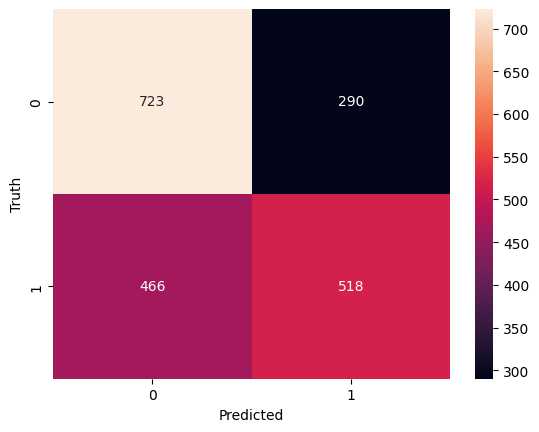

In [52]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train_bow,y_train)
y_pred_rf=rf.predict(X_test_bow)
accuracy_score(y_test,y_pred_rf)


0.8457686529794692

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Re-split the original X (DataFrame) and y (ndarray) to get the textual data for vectorization
X_train_text, X_test_text, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

cv=CountVectorizer(max_features=3000)
X_train_bow_limited = cv.fit_transform(X_train_text['review']).toarray()
X_test_bow_limited = cv.transform(X_test_text['review']).toarray()

rf=RandomForestClassifier()
rf.fit(X_train_bow_limited, y_train_new)
y_pred=rf.predict(X_test_bow_limited)
accuracy_score(y_test_new, y_pred)

0.8472709063595393

Text(50.722222222222214, 0.5, 'Truth')

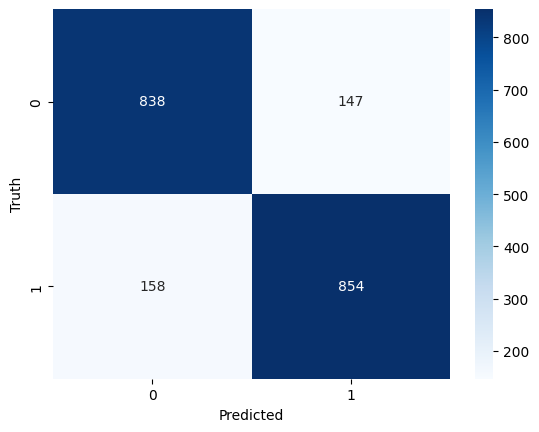

In [57]:
cm=confusion_matrix(y_test_new,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
